# Customer Churn Prediction & Retention Strategy System

This notebook walks through a complete end-to-end telecom churn project using the IBM Telco Customer Churn dataset.

**Project goals**
- Identify patterns behind customer churn
- Build machine learning models to predict churn (`Yes` / `No`)
- Translate the analysis into business insights and retention strategies

The notebook is designed to be beginner-friendly, but structured professionally enough for a portfolio or GitHub project.


## Step 1: Import Libraries


In [43]:
# Step 1: Import libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## Step 2: Load Dataset


In [44]:
# Step 2: Load the dataset

candidate_paths = [
    Path("WA_Fn-UseC_-Telco-Customer-Churn.csv"),
    Path("/Users/vasu/Customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
]

file_path = None
for path in candidate_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError(
        "Could not find the churn CSV file. Update the path in Step 2 to match your system."
    )

df = pd.read_csv(file_path)

print("Dataset loaded from:", file_path)
print("Dataset shape:", df.shape)
display(df.head())

print("\nDataset info:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all").T)


Dataset loaded from: /Users/vasu/Customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3: Data Cleaning


In [45]:
# Step 3: Data cleaning

# Keep a lightly cleaned copy for EDA so the original category labels remain readable in plots.
df_eda = df.copy()
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")
df_eda["TotalCharges"] = df_eda["TotalCharges"].fillna(0)
df_eda = df_eda.drop(columns=["customerID"], errors="ignore")

def clean_telco_data(dataframe):
    data = dataframe.copy()

    # TotalCharges is stored as text in the raw dataset, so we convert it to numeric.
    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

    # Blank TotalCharges values usually belong to brand-new customers with tenure = 0.
    data["TotalCharges"] = data["TotalCharges"].fillna(0)

    # customerID is only an identifier, so it is not useful for prediction.
    data = data.drop(columns=["customerID"], errors="ignore")

    yes_no_cols = []
    for col in data.columns:
        if data[col].dtype == "object":
            unique_values = set(data[col].dropna().unique())
            if unique_values.issubset({"Yes", "No"}):
                yes_no_cols.append(col)

    # Convert simple Yes/No fields to 1/0.
    for col in yes_no_cols:
        data[col] = data[col].map({"Yes": 1, "No": 0})

    return data, yes_no_cols

df_clean, binary_cols = clean_telco_data(df)

# Extract and convert Churn separately before one-hot encoding
churn_numeric = (df_clean["Churn"] == "Yes").astype(int)

# Drop Churn and encode the rest
df_clean_for_encoding = df_clean.drop("Churn", axis=1)
categorical_cols = df_clean_for_encoding.select_dtypes(include="object").columns.tolist()

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_clean_for_encoding, columns=categorical_cols, drop_first=True)

# Add Churn back as numeric
df_encoded.insert(4, "Churn", churn_numeric)

print("Binary Yes/No columns converted to 1/0:")
print(binary_cols)

print("\nRemaining categorical columns encoded with get_dummies():")
print(categorical_cols)

print("\nMissing values after cleaning:", int(df_encoded.isna().sum().sum()))
print("Cleaned dataset shape:", df_clean.shape)
print("Encoded dataset shape:", df_encoded.shape)
print("\nChurn column info:")
print("  - Present:", "Churn" in df_encoded.columns)
print("  - Data type:", df_encoded["Churn"].dtype)
print("  - Unique values:", sorted(df_encoded["Churn"].unique()))
print("  - Value counts:\n", df_encoded["Churn"].value_counts().sort_index())

display(df_clean.head())
display(df_encoded.head())


Binary Yes/No columns converted to 1/0:
[]

Remaining categorical columns encoded with get_dummies():
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Missing values after cleaning: 0
Cleaned dataset shape: (7043, 20)
Encoded dataset shape: (7043, 31)

Churn column info:
  - Present: True
  - Data type: int64
  - Unique values: [np.int64(0), np.int64(1)]
  - Value counts:
 Churn
0    5174
1    1869
Name: count, dtype: int64


/var/folders/nb/bld7cdfj11j0rl761f3zjkbc0000gn/T/ipykernel_6842/2126315888.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean_for_encoding.select_dtypes(include="object").columns.tolist()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Step 4: Exploratory Data Analysis (EDA)


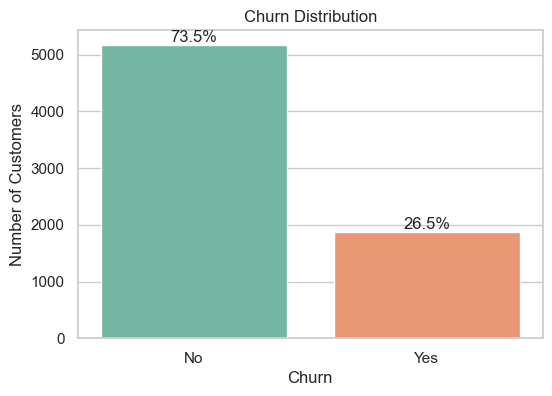

Overall churn rate: 26.54%


In [46]:
# Step 4A: Churn distribution

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_eda, x="Churn", hue="Churn", palette="Set2")
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

total_customers = len(df_eda)
for patch in ax.patches:
    percentage = 100 * patch.get_height() / total_customers
    ax.annotate(
        f"{percentage:.1f}%",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
    )

plt.show()

churn_rate = (df_eda["Churn"] == "Yes").mean()
print(f"Overall churn rate: {churn_rate:.2%}")

# Insight:
# If the dataset is imbalanced, accuracy alone can be misleading.
# That is why we will also check confusion matrices and classification reports later.


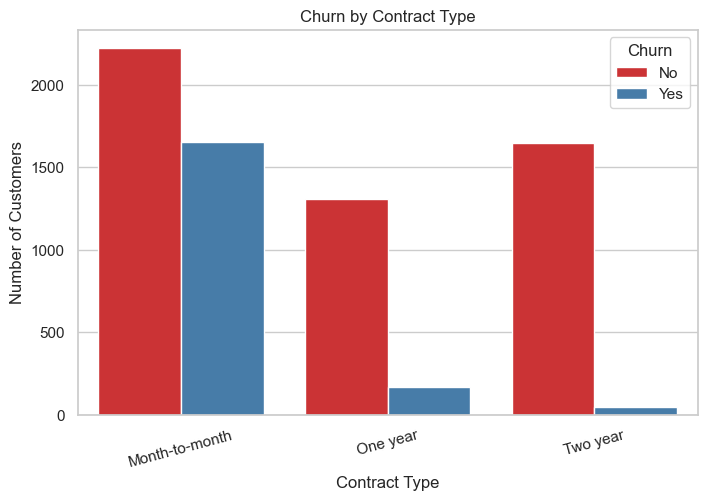

Churn rate by contract type:


,ChurnRate
Contract,
Month-to-month,42.71%
One year,11.27%
Two year,2.83%


In [47]:
# Step 4B: Analyze churn vs contract type

plt.figure(figsize=(8, 5))
sns.countplot(data=df_eda, x="Contract", hue="Churn", palette="Set1")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

contract_churn = (
    df_eda.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

print("Churn rate by contract type:")
display(contract_churn.apply(lambda x: f"{x:.2%}").to_frame("ChurnRate"))

# Insight:
# Month-to-month customers usually churn more because they have less commitment.
# Longer contracts often act as a built-in retention mechanism.


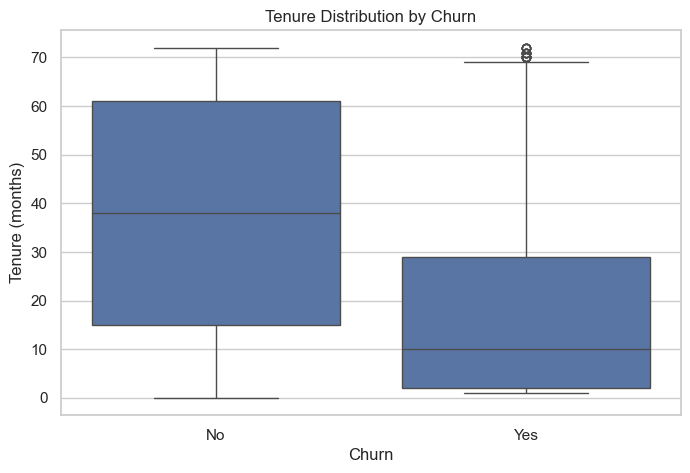

Tenure summary by churn:


,mean,median,min,max
Churn,,,,
No,37.57,38.0,0,72
Yes,17.98,10.0,1,72


In [48]:
# Step 4C: Analyze churn vs tenure

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="Churn", y="tenure")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

tenure_summary = df_eda.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"]).round(2)
print("Tenure summary by churn:")
display(tenure_summary)

# Insight:
# If churned customers have lower tenure, early customer experience is a major risk area.


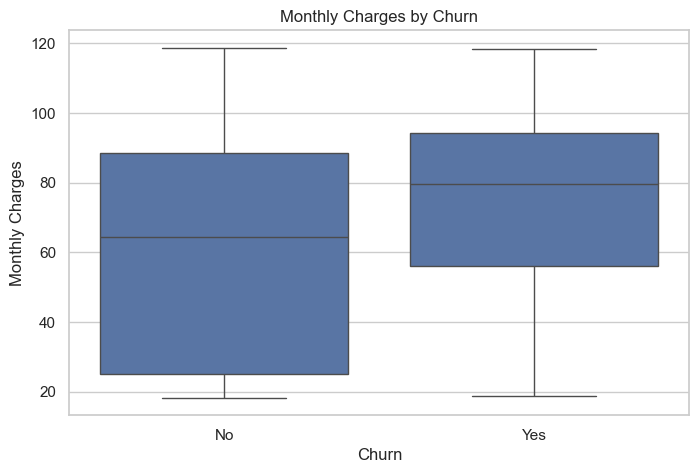

Monthly charge summary by churn:


,mean,median,min,max
Churn,,,,
No,61.27,64.43,18.25,118.75
Yes,74.44,79.65,18.85,118.35


In [49]:
# Step 4D: Analyze churn vs MonthlyCharges

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

monthly_summary = df_eda.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "min", "max"]).round(2)
print("Monthly charge summary by churn:")
display(monthly_summary)

# Insight:
# Higher monthly charges can increase churn, especially when customers do not see enough value.


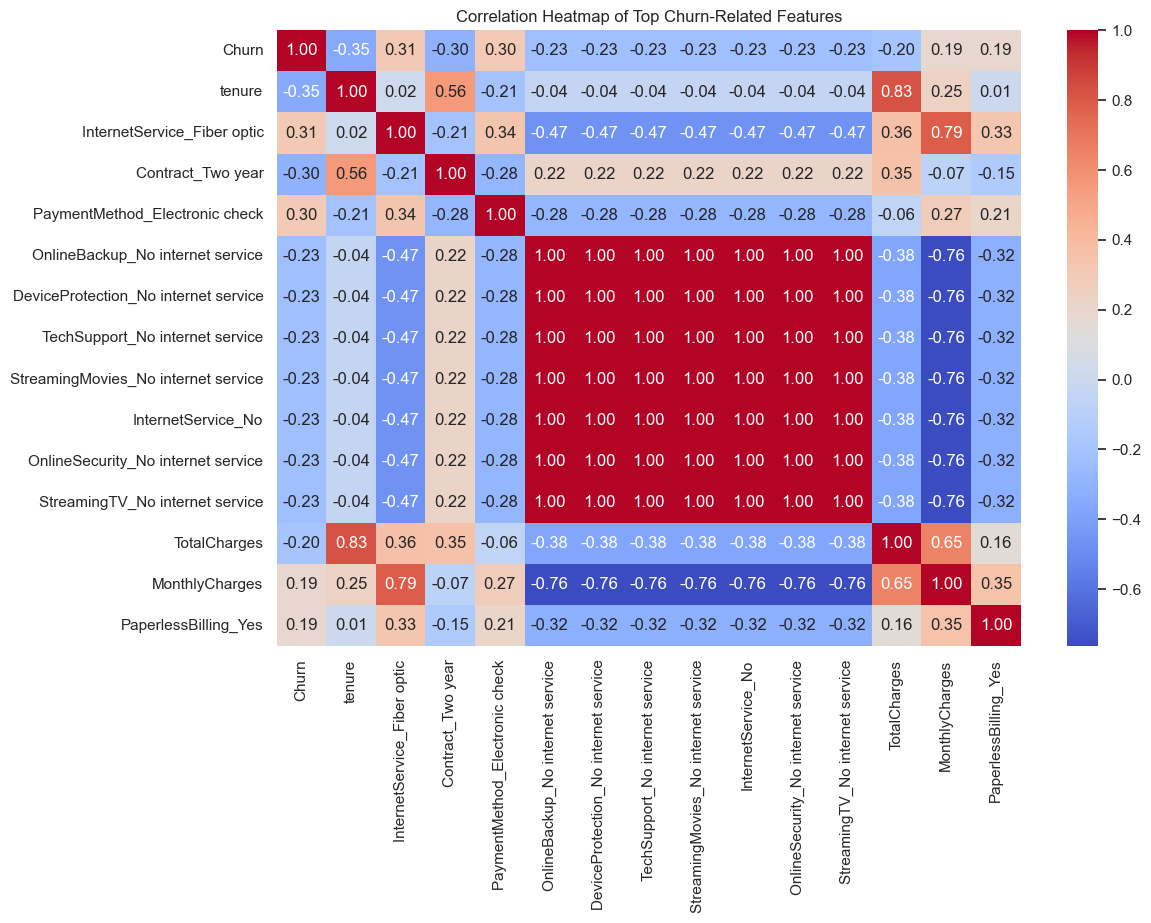

In [50]:
# Step 4E: Correlation heatmap

# A full heatmap becomes crowded after one-hot encoding, so we focus on the
# features that have the strongest correlation with churn.
corr_with_target = df_encoded.corr()["Churn"].sort_values(key=np.abs, ascending=False)
top_features = corr_with_target.head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded[top_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Top Churn-Related Features")
plt.show()


## Step 5: Feature Scaling


In [51]:
# Step 5: Feature scaling

X = df_encoded.drop("Churn", axis=1).astype(float)
y = df_encoded["Churn"]

scaler = StandardScaler()

print("Features prepared for modeling.")
print("StandardScaler selected. It will be fit only on the training set to avoid data leakage.")
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Features prepared for modeling.
StandardScaler selected. It will be fit only on the training set to avoid data leakage.
Feature matrix shape: (7043, 30)
Target vector shape: (7043,)


## Step 6: Model Building


In [52]:
# Step 6A: Split the data and train the models

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale only after splitting, so the test data remains unseen during fitting.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    solver="liblinear",
)
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
)

log_reg.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Both models trained successfully.")


Training set shape: (5634, 30)
Test set shape: (1409, 30)
Both models trained successfully.


Logistic Regression Accuracy: 0.7402

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



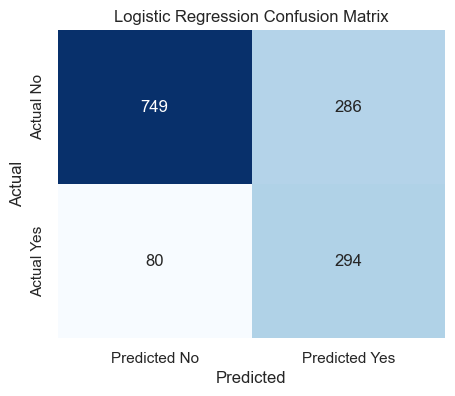

Random Forest Accuracy: 0.7864

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



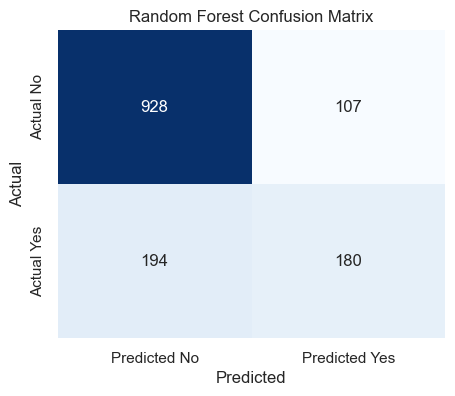

Model comparison:


,Model,Accuracy
1,Random Forest,0.786373
0,Logistic Regression,0.740241


In [53]:
# Step 6B: Evaluate the models

def logistic_probabilities(model, X_data):
    # Manual probability calculation keeps the workflow transparent and stable.
    linear_score = np.dot(np.asarray(X_data, dtype=float), model.coef_.ravel()) + model.intercept_[0]
    return 1 / (1 + np.exp(-linear_score))

def evaluate_predictions(model_name, y_true, y_pred):
    # Convert y_true to numeric if it contains strings
    if isinstance(y_true.iloc[0] if hasattr(y_true, 'iloc') else y_true[0], str):
        y_true_numeric = (y_true == "Yes").astype(int) if isinstance(y_true, pd.Series) else (y_true == "Yes").astype(int)
    else:
        y_true_numeric = y_true
    
    # Ensure both are numeric for comparison
    y_pred = np.asarray(y_pred, dtype=int)
    y_true_numeric = np.asarray(y_true_numeric, dtype=int)
    
    accuracy = accuracy_score(y_true_numeric, y_pred)

    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_numeric, y_pred))

    cm = confusion_matrix(y_true_numeric, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted No", "Predicted Yes"],
        yticklabels=["Actual No", "Actual Yes"],
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy

log_probabilities = logistic_probabilities(log_reg, X_test_scaled)
log_predictions = (log_probabilities >= 0.5).astype(int)
rf_predictions = rf_model.predict(X_test)

log_accuracy = evaluate_predictions("Logistic Regression", y_test, log_predictions)
rf_accuracy = evaluate_predictions("Random Forest", y_test, rf_predictions)

comparison_df = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "Accuracy": [log_accuracy, rf_accuracy],
    }
).sort_values("Accuracy", ascending=False)

print("Model comparison:")
display(comparison_df)


## Step 7: Feature Importance


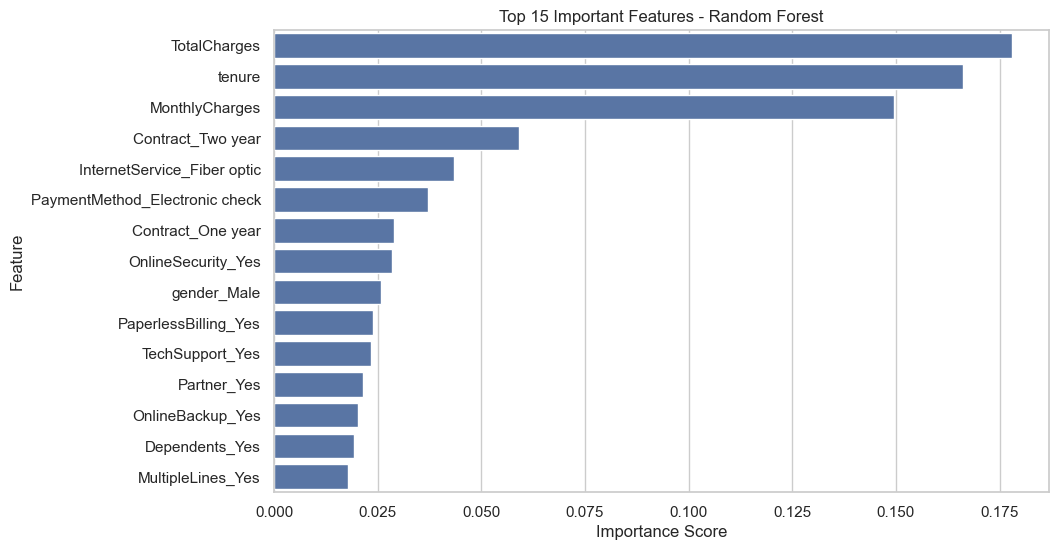

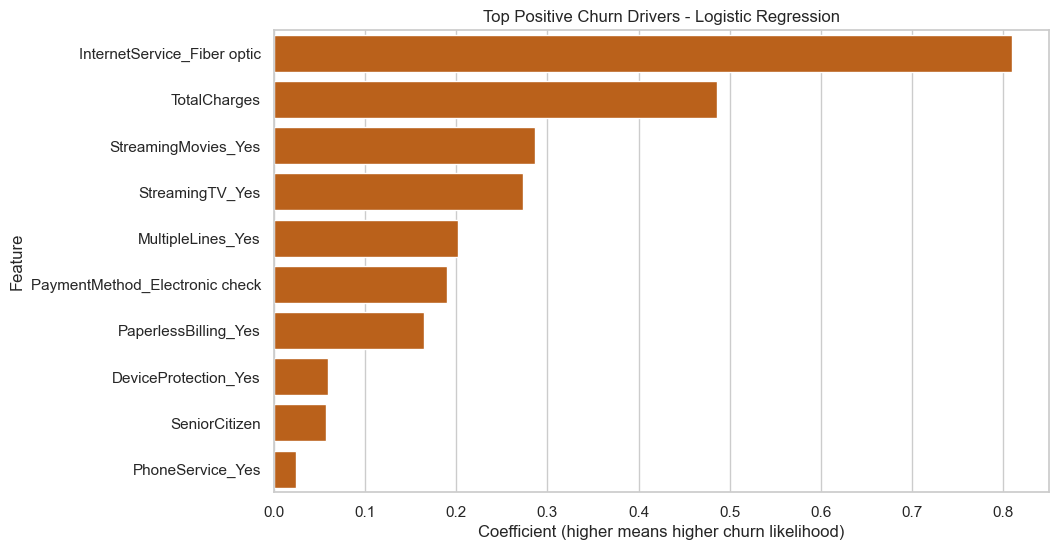

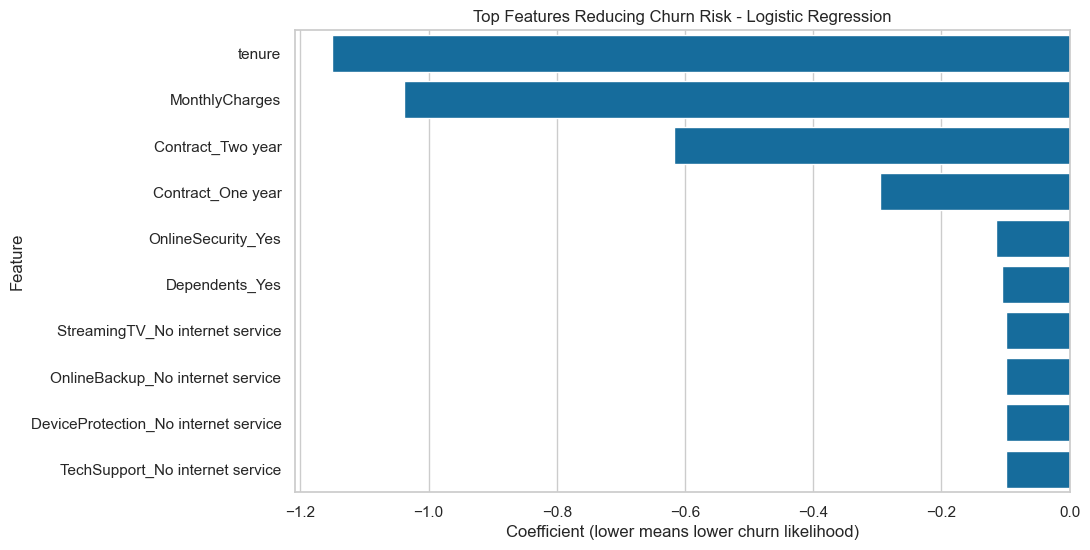

Top Random Forest features:


,Feature,Importance
3,TotalCharges,0.178041
1,tenure,0.166274
2,MonthlyCharges,0.149592
25,Contract_Two year,0.058970
10,InternetService_Fiber optic,0.043422
28,PaymentMethod_Electronic check,0.037218
24,Contract_One year,0.028888
13,OnlineSecurity_Yes,0.028352
4,gender_Male,0.025768
26,PaperlessBilling_Yes,0.023847


Top positive Logistic Regression coefficients:


,Feature,Coefficient
10,InternetService_Fiber optic,0.810253
3,TotalCharges,0.486068
23,StreamingMovies_Yes,0.286139
21,StreamingTV_Yes,0.273424
9,MultipleLines_Yes,0.201781
28,PaymentMethod_Electronic check,0.189255
26,PaperlessBilling_Yes,0.164604
17,DeviceProtection_Yes,0.058630
0,SeniorCitizen,0.056542
7,PhoneService_Yes,0.024486


In [54]:
# Step 7: Feature importance

rf_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": rf_model.feature_importances_,
    }
).sort_values("Importance", ascending=False)

log_coefficients = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": log_reg.coef_[0],
    }
).sort_values("Coefficient", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance.head(15), x="Importance", y="Feature", color="#4C72B0")
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=log_coefficients.head(10), x="Coefficient", y="Feature", color="#D55E00")
plt.title("Top Positive Churn Drivers - Logistic Regression")
plt.xlabel("Coefficient (higher means higher churn likelihood)")
plt.ylabel("Feature")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=log_coefficients.sort_values("Coefficient").head(10),
    x="Coefficient",
    y="Feature",
    color="#0072B2",
)
plt.title("Top Features Reducing Churn Risk - Logistic Regression")
plt.xlabel("Coefficient (lower means lower churn likelihood)")
plt.ylabel("Feature")
plt.show()

print("Top Random Forest features:")
display(rf_importance.head(15))

print("Top positive Logistic Regression coefficients:")
display(log_coefficients.head(10))


## Step 8: Business Insights


In [55]:
# Step 8: Business insights and retention strategy

contract_risk = (
    df_eda.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

tenure_band = pd.cut(
    df_eda["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
)
tenure_risk = (
    df_eda.assign(TenureBand=tenure_band)
    .groupby("TenureBand", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

charge_band = pd.qcut(df_eda["MonthlyCharges"], q=4, duplicates="drop")
charge_risk = (
    df_eda.assign(ChargeBand=charge_band)
    .groupby("ChargeBand", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

top_positive = log_coefficients.head(5)["Feature"].tolist()
top_negative = log_coefficients.sort_values("Coefficient").head(5)["Feature"].tolist()

print("BUSINESS INSIGHTS")
print("=" * 80)
print(f"1. High-risk customers are most commonly on '{contract_risk.index[0]}' contracts.")
print(f"   Churn rate for that group: {contract_risk.iloc[0]:.2%}")
print(f"2. The riskiest tenure band is '{tenure_risk.index[0]}'.")
print(f"   Churn rate for that band: {tenure_risk.iloc[0]:.2%}")
print("3. The highest-charge segment also shows elevated churn.")
print(f"   {str(charge_risk.index[0])} -> {charge_risk.iloc[0]:.2%}")
print()
print("KEY FACTORS CAUSING CHURN")
print("- Features increasing churn risk:", ", ".join(top_positive))
print("- Features associated with lower churn risk:", ", ".join(top_negative))
print()
print("SUGGESTED RETENTION STRATEGIES")
print("- Encourage month-to-month customers to move to 1-year or 2-year plans using discounts or bundle offers.")
print("- Focus onboarding and proactive service support on customers in their first 12 months.")
print("- Review pricing for high-bill customers and offer better-value plans or loyalty rewards.")
print("- Promote security/support add-ons if those features appear among the top churn drivers.")
print("- Use the churn model as an early-warning system so teams can intervene before cancellation.")

# These insights combine EDA patterns with model-based feature importance,
# which makes them easier to translate into business actions.


BUSINESS INSIGHTS
1. High-risk customers are most commonly on 'Month-to-month' contracts.
   Churn rate for that group: 42.71%
2. The riskiest tenure band is '0-12 months'.
   Churn rate for that band: 47.44%
3. The highest-charge segment also shows elevated churn.
   (70.35, 89.85] -> 37.51%

KEY FACTORS CAUSING CHURN
- Features increasing churn risk: InternetService_Fiber optic, TotalCharges, StreamingMovies_Yes, StreamingTV_Yes, MultipleLines_Yes
- Features associated with lower churn risk: tenure, MonthlyCharges, Contract_Two year, Contract_One year, OnlineSecurity_Yes

SUGGESTED RETENTION STRATEGIES
- Encourage month-to-month customers to move to 1-year or 2-year plans using discounts or bundle offers.
- Focus onboarding and proactive service support on customers in their first 12 months.
- Review pricing for high-bill customers and offer better-value plans or loyalty rewards.
- Promote security/support add-ons if those features appear among the top churn drivers.
- Use the churn 

## Step 9: Optional Bonus - Predict Churn for a New Customer


In [56]:
# Predict churn probability for a new sample customer

new_customer = pd.DataFrame(
    [
        {
            "gender": "Female",
            "SeniorCitizen": 0,
            "Partner": "No",
            "Dependents": "No",
            "tenure": 4,
            "PhoneService": "Yes",
            "MultipleLines": "No",
            "InternetService": "Fiber optic",
            "OnlineSecurity": "No",
            "OnlineBackup": "No",
            "DeviceProtection": "No",
            "TechSupport": "No",
            "StreamingTV": "Yes",
            "StreamingMovies": "Yes",
            "Contract": "Month-to-month",
            "PaperlessBilling": "Yes",
            "PaymentMethod": "Electronic check",
            "MonthlyCharges": 92.10,
            "TotalCharges": 368.40,
        }
    ]
)

new_customer_clean, _ = clean_telco_data(new_customer)
new_customer_encoded = pd.get_dummies(new_customer_clean, drop_first=True)

# Align the new record with the training feature columns.
new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)
new_customer_scaled = scaler.transform(new_customer_encoded)

new_customer_probability = logistic_probabilities(log_reg, new_customer_scaled)[0]
new_customer_prediction = int(new_customer_probability >= 0.5)

print("Predicted churn probability:", f"{new_customer_probability:.2%}")
print("Predicted class:", "Churn" if new_customer_prediction == 1 else "No Churn")

# Replace the values above with any real customer profile to score new cases.


Predicted churn probability: 18.64%
Predicted class: No Churn


## Final Note

You can now run this notebook top-to-bottom in Jupyter. If your CSV file is stored in a different location, only update the `candidate_paths` list in **Step 2**.
